In [44]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

In [10]:
res = np.arange(-16,16.01,0.1)

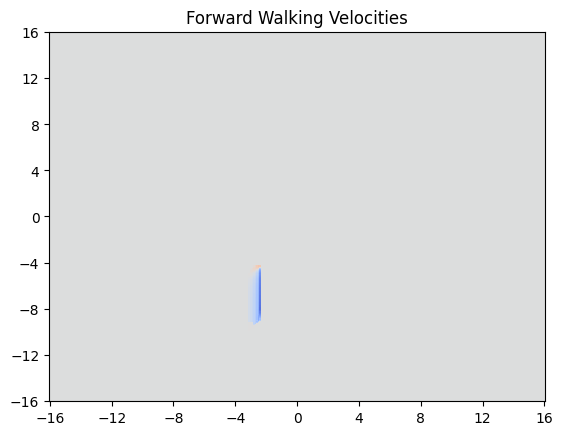

In [54]:
velocities_fw = np.loadtxt('./Forward Walkers/3/vel.dat').reshape((len(res),len(res)))
plt.pcolormesh(res,res,velocities_fw,cmap='coolwarm_r',vmin=-.627,vmax=.627)
plt.title('Forward Walking Velocities')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()

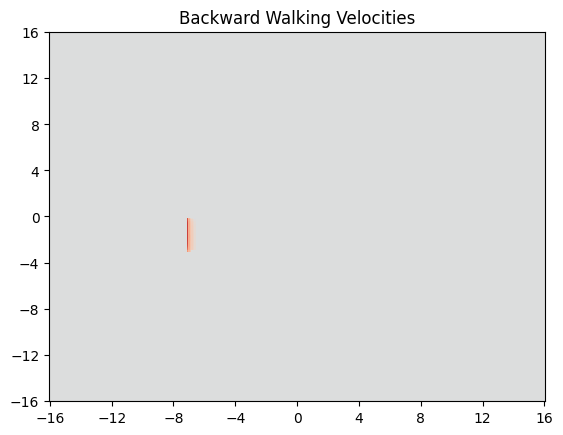

In [55]:
velocities_bw = np.loadtxt('./Backward Walkers/38/vel.dat').reshape((len(res),len(res)))
plt.pcolormesh(res,res,velocities_bw,cmap='coolwarm_r',vmin=-.627,vmax=.627)
plt.title('Backward Walking Velocities')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()

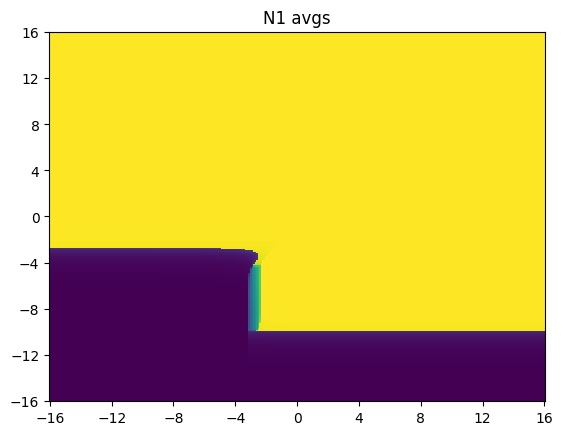

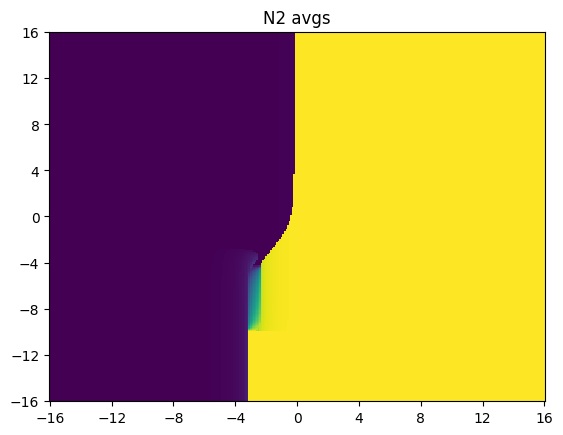

In [ ]:
avgs = np.loadtxt('./Forward Walkers/3/avgs.dat').reshape((len(res),len(res),2))
avgs[:,:,0] = ma.masked_where(velocities_fw<0,avgs[:,:,0])
avgs[:,:,1] = ma.masked_where(velocities_fw<0,avgs[:,:,1])
plt.pcolormesh(res,res,avgs[:,:,0],vmin=0,vmax=1)
plt.title('N1 avgs-fw')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()
plt.pcolormesh(res,res,avgs[:,:,1],vmin=0,vmax=1)
plt.title('N2 avgs-fw')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()

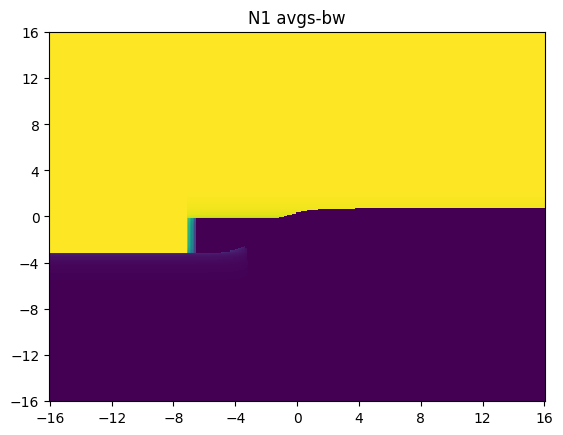

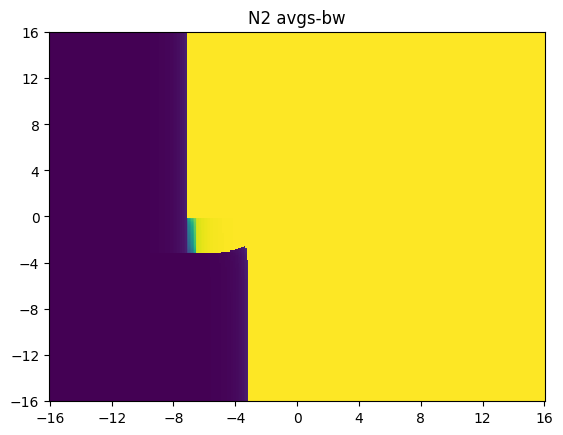

In [43]:
avgs = np.loadtxt('./Backward Walkers/38/avgs.dat').reshape((len(res),len(res),2))
avgs[:,:,0] = ma.masked_where(velocities_bw>0,avgs[:,:,0],copy=False)
avgs[:,:,1] = ma.masked_where(velocities_bw<0,avgs[:,:,1],copy=False)
plt.pcolormesh(res,res,avgs[:,:,0],vmin=0,vmax=1)
plt.title('N1 avgs-bw')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()
plt.pcolormesh(res,res,avgs[:,:,1],vmin=0,vmax=1)
plt.title('N2 avgs-bw')
plt.xticks(res.round(2)[::40])
plt.yticks(res.round(2)[::40])
plt.show()

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def imshow3d(ax, array, x=None, y=None, value_direction='z', pos=0, norm=None, cmap=None):
    """
    Display a 2D array as a color-coded image embedded in 3D using real coordinates.

    Parameters
    ----------
    ax : Axes3D
    array : 2D numpy array
    x, y : 1D arrays
        Real coordinate axes corresponding to array columns and rows.
    value_direction : {'x','y','z'}
        Axis perpendicular to the image plane.
    pos : float
        Location of the plane along value_direction.
    """

    if norm is None:
        norm = Normalize()

    colors = plt.get_cmap(cmap)(norm(array))

    ny, nx = array.shape

    if x is None:
        x = np.arange(nx + 1)
    if y is None:
        y = np.arange(ny + 1)

    xi, yi = np.meshgrid(x, y)

    if value_direction == 'z':
        zi = np.full_like(xi, pos)

    elif value_direction == 'x':
        zi, yi = np.meshgrid(x, y)
        xi = np.full_like(yi, pos)

    elif value_direction == 'y':
        xi, zi = np.meshgrid(x, y)
        yi = np.full_like(xi, pos)

    else:
        raise ValueError(f"Invalid value_direction: {value_direction!r}")

    ax.plot_surface(xi, yi, zi, rstride=1, cstride=1, facecolors=colors, shade=False)



In [73]:
np.arange(0,len(velocities_bw)+1,int(len(velocities_bw)/4))

array([  0,  80, 160, 240, 320])

In [124]:
paramseries = np.loadtxt('./neuralparameters.dat')

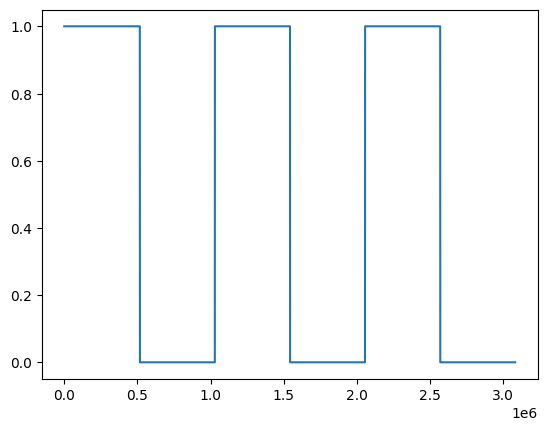

In [125]:
modulated = np.ones_like(paramseries[:,0])
modulated[np.where(paramseries[:,0]>-4.5)[0]]=0
plt.plot(modulated)

In [126]:
# plt.plot(paramseries[:,0],paramseries[:,1])
new_paramseries = np.zeros((len(paramseries),3))
new_paramseries[:,:-1] = paramseries
new_paramseries[:,-1] = modulated*5

/var/folders/gv/6v_0dsv15fzft0z3f6rw1zc40000gn/T/ipykernel_19712/559479281.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xticklabels=np.arange(-16,16.01,8),yticklabels=np.arange(-16,16.01,8))
/var/folders/gv/6v_0dsv15fzft0z3f6rw1zc40000gn/T/ipykernel_19712/559479281.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xticklabels=np.arange(-16,16.01,8),yticklabels=np.arange(-16,16.01,8))


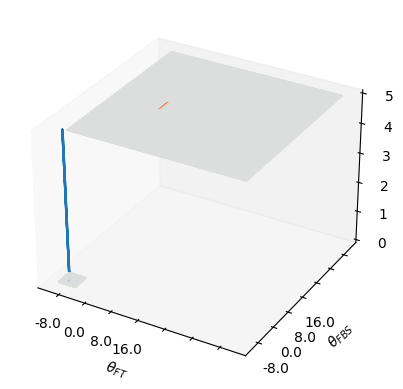

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set(xlabel=r'$\theta_{FT}$', ylabel=r'$\theta_{FBS}$', zlabel="")
# ax.set(xlim3d=[-16,16],ylim3d=[-16,16],zlim3d=[0,5])
ax.set(xticks=res,yticks=res,zticks=[])
ax.set(xticklabels=np.arange(-16,16.01,8),yticklabels=np.arange(-16,16.01,8))
ax.grid(False)

norm = Normalize(vmin=-0.627,vmax=0.627)

imshow3d(ax,velocities_fw,x=res,y=res ,cmap='coolwarm_r',norm=norm)
imshow3d(ax,velocities_bw,cmap='coolwarm_r',norm=norm,pos=5)
ax.plot3D(new_paramseries[:,0],new_paramseries[:,1],new_paramseries[:,2])

plt.show()